<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Matter008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

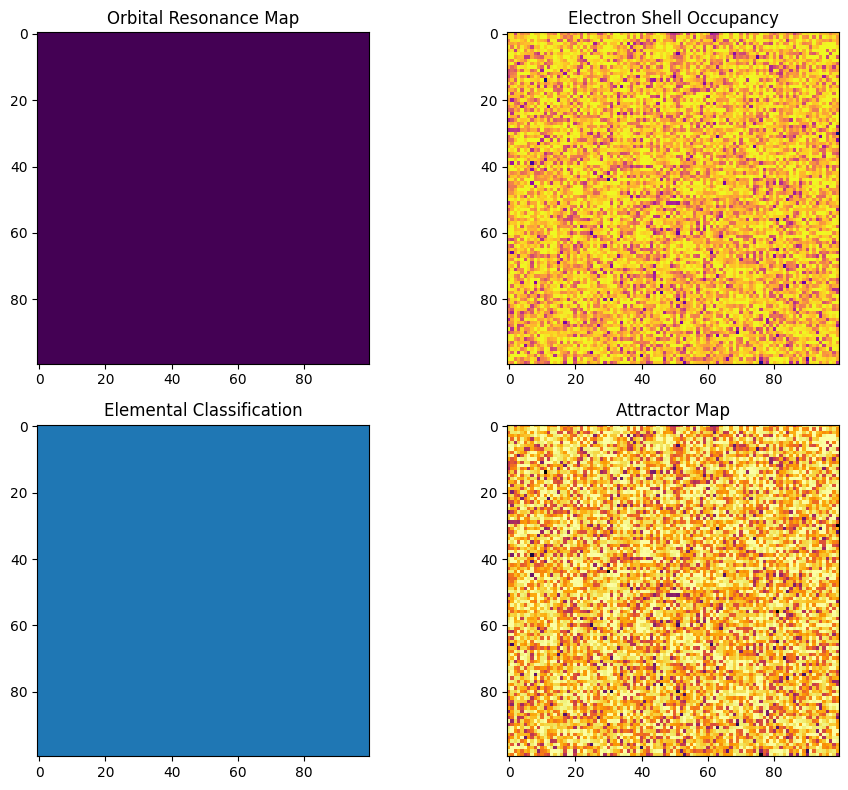

In [ ]:
# 🧪 Matter008: Orbital Resonance – HES Lattice Simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# --- Parameters ---
N = 100  # Lattice size
steps = 500
entropy_seed_strength = 0.1
curvature_threshold = 0.05
bonding_threshold = 0.6

# --- Initialize Lattice ---
S = np.random.rand(N, N) * entropy_seed_strength
curvature_memory = np.zeros_like(S)
attractor_map = np.zeros_like(S)

# --- Evolution Function ---
def evolve(S):
    grad_x, grad_y = np.gradient(S)
    laplacian = np.gradient(grad_x)[0] + np.gradient(grad_y)[1]
    return S - 0.01 * laplacian

# --- Simulation Loop ---
for t in range(steps):
    S = evolve(S)
    curvature = np.abs(np.gradient(np.gradient(S)[0])[0] + np.gradient(np.gradient(S)[1])[1])
    curvature_memory += curvature
    attractor_map += (curvature > curvature_threshold).astype(float)

# --- Entropy Flow & Coupling ---
grad_x, grad_y = np.gradient(S)
entropy_flow_magnitude = np.sqrt(grad_x**2 + grad_y**2)
coupling_strength = entropy_flow_magnitude * curvature_memory

# --- Bonding Map & Clusters ---
bonding_map = (coupling_strength > bonding_threshold).astype(float)
cluster_map, num_clusters = label(bonding_map)

# --- Orbital Quantization ---
shell_layers = np.zeros_like(S)
shell_layers[curvature_memory < 2] = 1  # s-orbital
shell_layers[(curvature_memory >= 2) & (curvature_memory < 4)] = 2  # p-orbital
shell_layers[(curvature_memory >= 4) & (curvature_memory < 6)] = 3  # d-orbital
shell_layers[curvature_memory >= 6] = 4  # f-orbital

# --- Electron Behavior ---
electron_distribution = entropy_flow_magnitude * attractor_map
charge_distribution = np.where(attractor_map > 0, np.random.choice([-1, 1], size=S.shape), 0)
shell_occupancy = shell_layers * attractor_map

# --- Ionization & Affinity ---
ionization_potential = curvature_memory * (charge_distribution == 1)
electron_affinity = curvature_memory * (charge_distribution == -1)

# --- Element Classification ---
element_classification = np.zeros_like(S)
element_classification[(shell_occupancy == 1)] = 1  # Group 1
element_classification[(shell_occupancy == 2)] = 2  # Group 2
element_classification[(shell_occupancy == 3)] = 13  # Group 13
element_classification[(shell_occupancy == 4)] = 14  # Group 14

# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(shell_layers, cmap='viridis'); axs[0, 0].set_title("Orbital Resonance Map")
axs[0, 1].imshow(shell_occupancy, cmap='plasma'); axs[0, 1].set_title("Electron Shell Occupancy")
axs[1, 0].imshow(element_classification, cmap='tab20'); axs[1, 0].set_title("Elemental Classification")
axs[1, 1].imshow(attractor_map, cmap='inferno'); axs[1, 1].set_title("Attractor Map")
plt.tight_layout(); plt.show()
